# Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load the core datasets

In [4]:
orders = pd.read_csv('../cleaned_data/orders_cleaned.csv')
customers = pd.read_csv('../cleaned_data/customers_cleaned.csv')
delivery_logs = pd.read_csv('../cleaned_data/delivery_logs_clean.csv')
fleet_vehicles = pd.read_csv('../cleaned_data/fleet_vehicles_cleaned.csv')

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Delivery Logs:", delivery_logs.shape)
print("Fleet Vehicles:", fleet_vehicles.shape)

Orders: (14427, 26)
Customers: (5000, 12)
Delivery Logs: (78756, 11)
Fleet Vehicles: (736, 15)


# verify the relationships

In [5]:
print("ORDERS")
print(orders.columns.tolist())

print("\nCUSTOMERS")
print(customers.columns.tolist())

print("\nDELIVERY LOGS")
print(delivery_logs.columns.tolist())

print("\nFLEET VEHICLES")
print(fleet_vehicles.columns.tolist())

ORDERS
['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status']

CUSTOMERS
['customer_id', 'customer_name', 'email', 'phone', 'city', 'state', 'pincode', 'signup_date', 'customer_segment', 'is_prime_member', 'lifetime_orders', 'avg_rating_given']

DELIVERY LOGS
['log_id', 'order_id', 'event_seq', 'event_type', 'event_timestamp', 'hub_code', 'vehicle_id', 'scanned_by_emp', 'location_city', 'remarks', 'exception_code']

FLEET VEHICLES
['vehicle_id', 'vehicle_type', 'model_name', 'capacity_kg', 'max_range_km', 'avg_speed_kmph', 'hub_code', 'purchase_date', 'odometer_km', 'fleet_status

# verify the keys

In [5]:
print("Unique customer IDs in customers:", customers['customer_id'].nunique())
print("Unique customer IDs in orders:", orders['customer_id'].nunique())

print("Unique order IDs in orders:", orders['order_id'].nunique())
print("Unique order IDs in delivery logs:", delivery_logs['order_id'].nunique())

print("Unique vehicle IDs in fleet:", fleet_vehicles['vehicle_id'].nunique())
print("Unique vehicle IDs in delivery logs:", delivery_logs['vehicle_id'].nunique())

Unique customer IDs in customers: 5000
Unique customer IDs in orders: 4707
Unique order IDs in orders: 14243
Unique order IDs in delivery logs: 15774
Unique vehicle IDs in fleet: 736
Unique vehicle IDs in delivery logs: 736


# inspect duplicate orders

In [6]:
duplicate_orders = orders[
    orders['order_id'].duplicated(keep=False)
].sort_values('order_id')

print(duplicate_orders[['order_id', 'customer_id', 'order_date',
                        'order_value_inr', 'order_status']].head(20))

print("Duplicate order rows:", len(duplicate_orders))

           order_id customer_id                 order_date  order_value_inr  \
11739   ORD-002039   CUST-01811  2025-07-03 12:44:00+00:00        372028.08   
12659   ORD-002039   CUST-01811  2025-07-03 12:44:00+00:00        372028.08   
4287    ORD-004562   CUST-03758  2025-03-22 19:23:00+00:00         79323.17   
13086   ORD-004562   CUST-03758  2025-03-22 19:23:00+00:00         79323.17   
7351    ORD-007964   CUST-01706  2025-02-14 09:31:00+00:00        705417.52   
10586   ORD-007964   CUST-01706  2025-02-14 09:31:00+00:00        705417.52   
7138    ORD-014480   CUST-03295  2024-06-05 09:05:00+00:00        148251.36   
9195    ORD-014480   CUST-03295  2024-06-05 09:05:00+00:00        148251.36   
7252     ORD-000022  CUST-01328  2024-02-29 17:23:00+00:00        222833.10   
7398     ORD-000022  CUST-01328  2024-02-29 17:23:00+00:00        222833.10   
5421     ORD-000101  CUST-01126  2024-08-10 11:17:00+00:00         19561.00   
10556    ORD-000101  CUST-01126  2024-08-10 11:17:00

# remove exact duplicate order records

In [7]:
print("Orders before:", len(orders))

orders = orders.drop_duplicates(subset='order_id', keep='first').copy()

print("Orders after:", len(orders))
print("Unique order IDs:", orders['order_id'].nunique())
print("Duplicate order IDs:", orders['order_id'].duplicated().sum())

Orders before: 14427
Orders after: 14243
Unique order IDs: 14243
Duplicate order IDs: 0


# check Delivery Logs coverage

In [8]:
order_ids = set(orders['order_id'])

delivery_logs['order_in_orders'] = delivery_logs['order_id'].isin(order_ids)

print(delivery_logs['order_in_orders'].value_counts())

print("\nDelivery-log orders found in Orders:",
      delivery_logs.loc[delivery_logs['order_in_orders'], 'order_id'].nunique())

print("Delivery-log orders NOT found in Orders:",
      delivery_logs.loc[~delivery_logs['order_in_orders'], 'order_id'].nunique())

order_in_orders
True     71334
False     7422
Name: count, dtype: int64

Delivery-log orders found in Orders: 13745
Delivery-log orders NOT found in Orders: 2029


# inspect event types

In [9]:
print(delivery_logs['event_type'].value_counts())

event_type
ORDER_PLACED        15000
PICKED_UP           15000
DELIVERED           12773
AT_HUB              11295
IN_TRANSIT          11250
OUT_FOR_DELIVERY    11211
FAILED_ATTEMPT       1314
RTO_INITIATED         913
Name: count, dtype: int64


# create order-level delivery features

In [10]:
delivery_summary = (
    delivery_logs
    .groupby('order_id')
    .agg(
        delivery_event_count=('event_type', 'size'),
        failed_attempt_count=('event_type', lambda x: (x == 'FAILED_ATTEMPT').sum()),
        rto_count=('event_type', lambda x: (x == 'RTO_INITIATED').sum()),
        hub_event_count=('event_type', lambda x: (x == 'AT_HUB').sum()),
        delivery_log_start=('event_timestamp', 'min'),
        delivery_log_end=('event_timestamp', 'max')
    )
    .reset_index()
)

print(delivery_summary.shape)
print(delivery_summary.head())

(15774, 7)
     order_id  delivery_event_count  failed_attempt_count  rto_count  \
0  ORD-000001                     6                     0          0   
1  ORD-000002                     4                     0          0   
2  ORD-000003                     6                     0          0   
3  ORD-000004                     6                     0          0   
4  ORD-000005                     5                     0          0   

   hub_event_count         delivery_log_start           delivery_log_end  
0                1  2024-11-11 23:32:06+00:00  2024-12-11 20:46:02+00:00  
1                0  2024-09-25 15:35:54+00:00  2024-09-25 16:58:23+00:00  
2                1  2025-04-13 06:36:00+00:00  2025-04-13 07:44:37+00:00  
3                1  2025-06-07 19:13:00+00:00  2025-08-06 18:52:21+00:00  
4                1  2025-02-27 00:00:00+00:00  2025-02-27 20:31:02+00:00  


# Add the vehicle information

In [11]:
vehicle_per_order = (
    delivery_logs
    .groupby('order_id')['vehicle_id']
    .nunique()
)

print(vehicle_per_order.value_counts().sort_index())

vehicle_id
1     763
2      32
3     412
4    4110
5    4594
6    5863
Name: count, dtype: int64


# Add vehicle_count

In [12]:
vehicle_summary = (
    delivery_logs
    .groupby('order_id')['vehicle_id']
    .nunique()
    .reset_index(name='vehicle_count')
)

print(vehicle_summary.head())
print("\nVehicle count distribution:")
print(vehicle_summary['vehicle_count'].value_counts().sort_index())

     order_id  vehicle_count
0  ORD-000001              6
1  ORD-000002              4
2  ORD-000003              6
3  ORD-000004              6
4  ORD-000005              5

Vehicle count distribution:
vehicle_count
1     763
2      32
3     412
4    4110
5    4594
6    5863
Name: count, dtype: int64


# combine the two summaries

In [13]:
delivery_summary = delivery_summary.merge(
    vehicle_summary,
    on='order_id',
    how='left'
)

print(delivery_summary.shape)
print(delivery_summary.head())

(15774, 8)
     order_id  delivery_event_count  failed_attempt_count  rto_count  \
0  ORD-000001                     6                     0          0   
1  ORD-000002                     4                     0          0   
2  ORD-000003                     6                     0          0   
3  ORD-000004                     6                     0          0   
4  ORD-000005                     5                     0          0   

   hub_event_count         delivery_log_start           delivery_log_end  \
0                1  2024-11-11 23:32:06+00:00  2024-12-11 20:46:02+00:00   
1                0  2024-09-25 15:35:54+00:00  2024-09-25 16:58:23+00:00   
2                1  2025-04-13 06:36:00+00:00  2025-04-13 07:44:37+00:00   
3                1  2025-06-07 19:13:00+00:00  2025-08-06 18:52:21+00:00   
4                1  2025-02-27 00:00:00+00:00  2025-02-27 20:31:02+00:00   

   vehicle_count  
0              6  
1              4  
2              6  
3              6  
4   

## merge delivery features into Orders

In [14]:
orders_analysis = orders.merge(
    delivery_summary,
    on='order_id',
    how='left'
)

print("Orders before merge:", len(orders))
print("Orders after merge:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

print("\nDelivery summary matched:")
print(orders_analysis['delivery_event_count'].notna().value_counts())

Orders before merge: 14243
Orders after merge: 14243
Columns: 33

Delivery summary matched:
delivery_event_count
True     13745
False      498
Name: count, dtype: int64


# verify the new delivery features

In [15]:
print(
    orders_analysis[
        [
            'order_id',
            'promised_eta_hours',
            'actual_delivery_hours',
            'delivery_event_count',
            'failed_attempt_count',
            'rto_count',
            'hub_event_count',
            'vehicle_count'
        ]
    ].head(10)
)

     order_id  promised_eta_hours  actual_delivery_hours  \
0  ORD-011545                22.6                  17.72   
1  ORD-008131                 3.2                   3.01   
2  ORD-005235                 1.6                   1.29   
3  ORD-001394                 5.8                   5.51   
4  ORD-011091                75.1                  57.61   
5  ORD-005379                 0.4                   0.33   
6  ORD-011641                14.2                   9.24   
7  ORD-006654                 1.1                   1.02   
8  ORD-012807                17.1                  11.80   
9  ORD-002865                 0.4                   0.30   

   delivery_event_count  failed_attempt_count  rto_count  hub_event_count  \
0                   5.0                   0.0        0.0              1.0   
1                   4.0                   0.0        0.0              0.0   
2                   6.0                   0.0        0.0              1.0   
3                   4.0        

In [16]:
print(orders_analysis[
    [
        'delivery_event_count',
        'failed_attempt_count',
        'rto_count',
        'hub_event_count',
        'vehicle_count'
    ]
].describe())

       delivery_event_count  failed_attempt_count     rto_count  \
count          13745.000000          13745.000000  13745.000000   
mean               5.189814              0.085777      0.060968   
std                0.859438              0.280044      0.239280   
min                1.000000              0.000000      0.000000   
25%                4.000000              0.000000      0.000000   
50%                5.000000              0.000000      0.000000   
75%                6.000000              0.000000      0.000000   
max                6.000000              1.000000      1.000000   

       hub_event_count  vehicle_count  
count     13745.000000   13745.000000  
mean          0.745216       5.050127  
std           0.435755       0.897402  
min           0.000000       1.000000  
25%           0.000000       4.000000  
50%           1.000000       5.000000  
75%           1.000000       6.000000  
max           1.000000       6.000000  


# create the main delivery-performance features

In [17]:
orders_analysis['delivery_delay_hours'] = (
    orders_analysis['actual_delivery_hours']
    - orders_analysis['promised_eta_hours']
)

orders_analysis['delivery_delay_pct'] = (
    orders_analysis['delivery_delay_hours']
    / orders_analysis['promised_eta_hours']
) * 100

orders_analysis['on_time'] = (
    orders_analysis['delivery_delay_hours'] <= 0
)

print(
    orders_analysis[
        [
            'order_id',
            'promised_eta_hours',
            'actual_delivery_hours',
            'delivery_delay_hours',
            'delivery_delay_pct',
            'on_time'
        ]
    ].head(10)
)

     order_id  promised_eta_hours  actual_delivery_hours  \
0  ORD-011545                22.6                  17.72   
1  ORD-008131                 3.2                   3.01   
2  ORD-005235                 1.6                   1.29   
3  ORD-001394                 5.8                   5.51   
4  ORD-011091                75.1                  57.61   
5  ORD-005379                 0.4                   0.33   
6  ORD-011641                14.2                   9.24   
7  ORD-006654                 1.1                   1.02   
8  ORD-012807                17.1                  11.80   
9  ORD-002865                 0.4                   0.30   

   delivery_delay_hours  delivery_delay_pct  on_time  
0                 -4.88          -21.592920     True  
1                 -0.19           -5.937500     True  
2                 -0.31          -19.375000     True  
3                 -0.29           -5.000000     True  
4                -17.49          -23.288948     True  
5        

# check the overall delivery performance

In [18]:
print("Total orders:", len(orders_analysis))

print("\nOn-time delivery:")
print(orders_analysis['on_time'].value_counts())

print("\nOn-time percentage:")
print(orders_analysis['on_time'].mean() * 100)

print("\nDelivery delay statistics:")
print(orders_analysis['delivery_delay_hours'].describe())

Total orders: 14243

On-time delivery:
on_time
True     13945
False      298
Name: count, dtype: int64

On-time percentage:
97.90774415502352

Delivery delay statistics:
count    14243.000000
mean        -4.599070
std          7.601564
min       -115.100000
25%         -5.840000
50%         -1.650000
75%         -0.430000
max          7.900000
Name: delivery_delay_hours, dtype: float64


In [19]:
late_orders = orders_analysis[
    orders_analysis['on_time'] == False
].copy()

print("Late orders:", len(late_orders))

print("\nLate order statistics:")
print(late_orders['delivery_delay_hours'].describe())

Late orders: 298

Late order statistics:
count    298.000000
mean       5.340034
std        2.072221
min        0.010000
25%        3.925000
50%        5.950000
75%        7.000000
max        7.900000
Name: delivery_delay_hours, dtype: float64


In [20]:
comparison = orders_analysis.groupby('on_time')[
    [
        'distance_km',
        'package_weight',
        'order_value_inr',
        'delivery_cost_inr',
        'delivery_event_count',
        'vehicle_count',
        'failed_attempt_count',
        'rto_count'
    ]
].mean()

print(comparison)

         distance_km  package_weight  order_value_inr  delivery_cost_inr  \
on_time                                                                    
False     352.333456      906.103389    237637.456007        2004.145953   
True     1353.341697      748.966652    241508.184516        4419.808694   

         delivery_event_count  vehicle_count  failed_attempt_count  rto_count  
on_time                                                                        
False                5.160839       5.111888              0.111888   0.073427  
True                 5.190430       5.048815              0.085222   0.060703  


In [21]:
mode_performance = orders_analysis.groupby('transport_mode').agg(
    total_orders=('order_id', 'count'),
    late_orders=('on_time', lambda x: (~x).sum()),
    on_time_rate=('on_time', 'mean'),
    avg_delay=('delivery_delay_hours', 'mean')
).reset_index()

mode_performance['late_rate'] = (
    mode_performance['late_orders'] /
    mode_performance['total_orders'] * 100
)

print(mode_performance.sort_values('late_rate', ascending=False))

  transport_mode  total_orders  late_orders  on_time_rate  avg_delay  \
1           bike          3417          148      0.956687  -0.550088   
2          drone           781           29      0.962868  -0.998118   
5            van          2025           69      0.965926  -1.088059   
4          truck          5862           50      0.991470  -8.658301   
0      air cargo          1917            2      0.998957  -2.880746   
3           ship           241            0      1.000000 -18.110830   

   late_rate  
1   4.331285  
2   3.713188  
5   3.407407  
4   0.852951  
0   0.104330  
3   0.000000  


# visualize

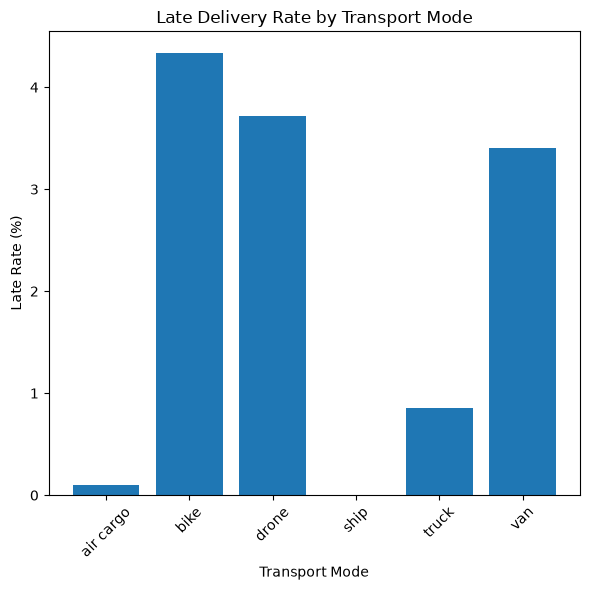

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.bar(
    mode_performance['transport_mode'],
    mode_performance['late_rate']
)

plt.title('Late Delivery Rate by Transport Mode')
plt.xlabel('Transport Mode')
plt.ylabel('Late Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

delivery priority

In [23]:
priority_performance = orders_analysis.groupby('delivery_priority').agg(
    total_orders=('order_id', 'count'),
    late_orders=('on_time', lambda x: (~x).sum()),
    on_time_rate=('on_time', 'mean'),
    avg_delay=('delivery_delay_hours', 'mean')
).reset_index()

priority_performance['late_rate'] = (
    priority_performance['late_orders'] /
    priority_performance['total_orders'] * 100
)

print(priority_performance.sort_values('late_rate', ascending=False))

  delivery_priority  total_orders  late_orders  on_time_rate  avg_delay  \
3          standard          7134          160      0.977572  -5.795870   
2          same-day          1748           36      0.979405  -2.791579   
1           express          3913           80      0.979555  -2.808692   
0           economy          1448           22      0.984807  -5.722880   

   late_rate  
3   2.242781  
2   2.059497  
1   2.044467  
0   1.519337  


city-level late delivery

In [24]:
city_performance = orders_analysis.groupby('destination_city').agg(
    total_orders=('order_id', 'count'),
    late_orders=('on_time', lambda x: (~x).sum()),
    on_time_rate=('on_time', 'mean'),
    avg_delay=('delivery_delay_hours', 'mean')
).reset_index()

city_performance['late_rate'] = (
    city_performance['late_orders'] /
    city_performance['total_orders'] * 100
)

print(city_performance.sort_values('late_rate', ascending=False))

   destination_city  total_orders  late_orders  on_time_rate  avg_delay  \
14         GURUGRAM            48            4      0.916667  -2.867500   
2         BENGALURU            38            2      0.947368  -3.818947   
8        COIMBATORE            42            2      0.952381  -5.266429   
29           MUMBAI            44            2      0.954545  -5.290909   
18        HYDERABAD            60            2      0.966667  -4.221333   
24            Kochi           667           22      0.967016  -5.061664   
5       Bhubaneswar           685           21      0.969343  -4.033226   
25          Kolkata           626           18      0.971246  -5.221534   
21           Jaipur           661           19      0.971256  -4.429107   
20           JAIPUR            38            1      0.973684  -5.168158   
34           NAGPUR            40            1      0.975000  -4.673250   
16         Gurugram           698           17      0.975645  -4.285516   
17         Guwahati      

In [25]:
city_performance = orders_analysis.groupby('destination_city').agg(
    total_orders=('order_id', 'count'),
    late_orders=('on_time', lambda x: (~x).sum()),
    on_time_rate=('on_time', 'mean'),
    avg_delay=('delivery_delay_hours', 'mean')
).reset_index()

city_performance['late_rate'] = (
    city_performance['late_orders'] /
    city_performance['total_orders'] * 100
)

print(city_performance.sort_values('late_rate', ascending=False))

   destination_city  total_orders  late_orders  on_time_rate  avg_delay  \
14         GURUGRAM            48            4      0.916667  -2.867500   
2         BENGALURU            38            2      0.947368  -3.818947   
8        COIMBATORE            42            2      0.952381  -5.266429   
29           MUMBAI            44            2      0.954545  -5.290909   
18        HYDERABAD            60            2      0.966667  -4.221333   
24            Kochi           667           22      0.967016  -5.061664   
5       Bhubaneswar           685           21      0.969343  -4.033226   
25          Kolkata           626           18      0.971246  -5.221534   
21           Jaipur           661           19      0.971256  -4.429107   
20           JAIPUR            38            1      0.973684  -5.168158   
34           NAGPUR            40            1      0.975000  -4.673250   
16         Gurugram           698           17      0.975645  -4.285516   
17         Guwahati      

In [26]:
print(orders_analysis['destination_city'].head(20))
print("\nUnique city names:", orders_analysis['destination_city'].nunique())
print("\nUppercase examples:")
print(orders_analysis[
    orders_analysis['destination_city'].str.isupper()
]['destination_city'].value_counts().head(20))

0      CHANDIGARH
1         Chennai
2       Bengaluru
3         Madurai
4        Guwahati
5          Mumbai
6     Bhubaneswar
7      Chandigarh
8         Chennai
9          Jaipur
10      Ahmedabad
11       Guwahati
12       Guwahati
13    BHUBANESWAR
14     Coimbatore
15        Lucknow
16        Chennai
17      Ahmedabad
18       Gurugram
19        Kolkata
Name: destination_city, dtype: str

Unique city names: 40

Uppercase examples:
destination_city
BHUBANESWAR      64
HYDERABAD        60
CHANDIGARH       49
DELHI            48
GURUGRAM         48
KOCHI            46
MYSURU           45
MUMBAI           44
COIMBATORE       42
MADURAI          41
KOLKATA          40
NAGPUR           40
CHENNAI          39
BENGALURU        38
JAIPUR           38
GUWAHATI         38
VISAKHAPATNAM    37
LUCKNOW          37
AHMEDABAD        36
PUNE             31
Name: count, dtype: int64


In [27]:
orders_analysis['destination_city'] = (
    orders_analysis['destination_city']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)

print("Unique city names:", orders_analysis['destination_city'].nunique())
print(orders_analysis['destination_city'].value_counts())

Unique city names: 20
destination_city
Ahmedabad        755
Chandigarh       749
Bhubaneswar      749
Gurugram         746
Pune             744
Lucknow          720
Hyderabad        718
Kochi            713
Guwahati         712
Nagpur           711
Delhi            710
Madurai          709
Chennai          708
Mysuru           706
Coimbatore       705
Jaipur           699
Mumbai           685
Bengaluru        679
Kolkata          666
Visakhapatnam    659
Name: count, dtype: int64


Rerun city performance

In [28]:
city_performance = orders_analysis.groupby('destination_city').agg(
    total_orders=('order_id', 'count'),
    late_orders=('on_time', lambda x: (~x).sum()),
    on_time_rate=('on_time', 'mean'),
    avg_delay=('delivery_delay_hours', 'mean')
).reset_index()

city_performance['late_rate'] = (
    city_performance['late_orders'] /
    city_performance['total_orders'] * 100
)

print(city_performance.sort_values('late_rate', ascending=False))

   destination_city  total_orders  late_orders  on_time_rate  avg_delay  \
11            Kochi           713           23      0.967742  -5.269229   
2       Bhubaneswar           749           22      0.970628  -4.022657   
10           Jaipur           699           20      0.971388  -4.469285   
7          Gurugram           746           21      0.971850  -4.194276   
12          Kolkata           666           18      0.972973  -5.361321   
15           Mumbai           685           16      0.976642  -4.467241   
8          Guwahati           712           16      0.977528  -5.970042   
3        Chandigarh           749           16      0.978638  -4.914246   
16           Mysuru           706           15      0.978754  -4.682776   
19    Visakhapatnam           659           14      0.978756  -4.240379   
5        Coimbatore           705           14      0.980142  -5.006908   
17           Nagpur           711           14      0.980309  -3.728819   
13          Lucknow      

# Create the city chart

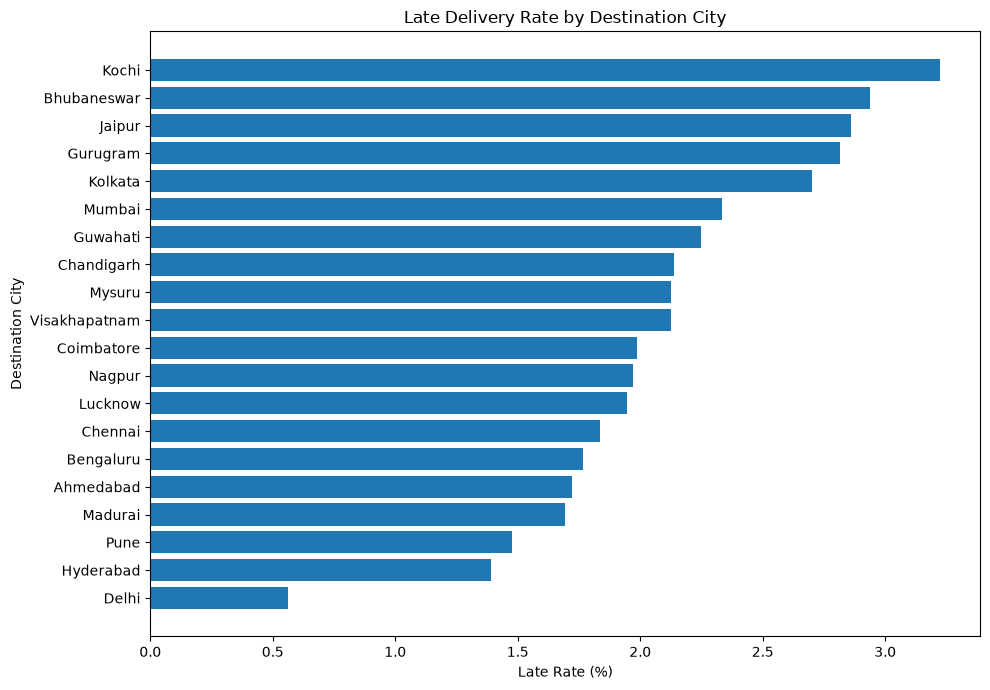

In [29]:
import matplotlib.pyplot as plt

city_chart = city_performance.sort_values('late_rate', ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    city_chart['destination_city'],
    city_chart['late_rate']
)

plt.title('Late Delivery Rate by Destination City')
plt.xlabel('Late Rate (%)')
plt.ylabel('Destination City')
plt.tight_layout()
plt.show()

# Traffic impact on late deliveries

In [30]:
traffic_data = pd.read_csv('../cleaned_data/traffic_data_cleaned.csv')

print(traffic_data.shape)
print(traffic_data.columns.tolist())
print(traffic_data.head())

(19728, 8)
['record_date', 'hour_of_day', 'city', 'corridor', 'congestion_index', 'avg_speed_kmph', 'incident_reported', 'road_closure']
                 record_date  hour_of_day     city        corridor  \
0  2024-01-01 00:00:00+00:00            7  Kolkata  Central Market   
1  2024-01-01 00:00:00+00:00           10  Kolkata   NH-44 Stretch   
2  2024-01-01 00:00:00+00:00           13  Kolkata     IT Corridor   
3  2024-01-01 00:00:00+00:00           17  Kolkata   NH-44 Stretch   
4  2024-01-01 00:00:00+00:00           20  Kolkata     IT Corridor   

   congestion_index  avg_speed_kmph  incident_reported road_closure  
0             0.540            31.9              False        False  
1             0.259            37.7               True        False  
2             0.369            40.5              False        False  
3             0.774            15.5              False        False  
4             0.644            21.6               True        False  


# create the matching date and hour in Orders

In [31]:
orders_analysis['order_date_dt'] = pd.to_datetime(
    orders_analysis['order_date'],
    errors='coerce'
)

orders_analysis['traffic_date'] = (
    orders_analysis['order_date_dt']
    .dt.floor('D')
)

orders_analysis['traffic_hour'] = (
    orders_analysis['order_date_dt']
    .dt.hour
)

traffic_data['traffic_date'] = pd.to_datetime(
    traffic_data['record_date'],
    errors='coerce'
).dt.floor('D')

print(
    orders_analysis[
        ['order_date', 'destination_city',
         'traffic_date', 'traffic_hour']
    ].head()
)

                  order_date destination_city              traffic_date  \
0  2024-05-06 00:00:00+00:00       Chandigarh 2024-05-06 00:00:00+00:00   
1  2024-12-27 12:23:00+00:00          Chennai 2024-12-27 00:00:00+00:00   
2  2024-11-18 12:58:00+00:00        Bengaluru 2024-11-18 00:00:00+00:00   
3  2024-08-29 11:05:00+00:00          Madurai 2024-08-29 00:00:00+00:00   
4  2025-04-28 21:44:00+00:00         Guwahati 2025-04-28 00:00:00+00:00   

   traffic_hour  
0             0  
1            12  
2            12  
3            11  
4            21  


# check whether traffic has duplicate matching keys

In [32]:
traffic_key_counts = (
    traffic_data
    .groupby(['traffic_date', 'city', 'hour_of_day'])
    .size()
)

print("Duplicate traffic keys:")
print(traffic_key_counts[traffic_key_counts > 1].head(20))

print("\nNumber of duplicated keys:",
      (traffic_key_counts > 1).sum())

Duplicate traffic keys:
Series([], dtype: int64)

Number of duplicated keys: 0


# merge traffic into Orders

In [33]:
orders_analysis = orders_analysis.merge(
    traffic_data[
        [
            'traffic_date',
            'city',
            'hour_of_day',
            'congestion_index',
            'avg_speed_kmph',
            'incident_reported',
            'road_closure'
        ]
    ],
    left_on=['traffic_date', 'destination_city', 'traffic_hour'],
    right_on=['traffic_date', 'city', 'hour_of_day'],
    how='left',
    validate='many_to_one'
)

print("Orders after traffic merge:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

print("\nTraffic match:")
print(orders_analysis['congestion_index'].notna().value_counts())

Orders after traffic merge: 14243
Columns: 45

Traffic match:
congestion_index
False    13102
True      1141
Name: count, dtype: int64


# check why traffic matching is low

In [34]:
print("Orders with traffic:", orders_analysis['congestion_index'].notna().sum())
print("Orders without traffic:", orders_analysis['congestion_index'].isna().sum())

print("\nTraffic date range:")
print(traffic_data['traffic_date'].min(), "to", traffic_data['traffic_date'].max())

print("\nOrders date range:")
print(orders_analysis['traffic_date'].min(), "to", orders_analysis['traffic_date'].max())

Orders with traffic: 1141
Orders without traffic: 13102

Traffic date range:
2024-01-01 00:00:00+00:00 to 2025-06-30 00:00:00+00:00

Orders date range:
2024-01-01 00:00:00+00:00 to 2025-12-06 00:00:00+00:00


# Quantify the overlap properly

In [35]:
traffic_available = orders_analysis['congestion_index'].notna()

print("Orders with traffic data:", traffic_available.sum())
print("Orders without traffic data:", (~traffic_available).sum())

print("\nLate orders with traffic data:")
print(
    orders_analysis.loc[
        traffic_available,
        'on_time'
    ].value_counts()
)

print("\nLate orders without traffic data:")
print(
    orders_analysis.loc[
        ~traffic_available,
        'on_time'
    ].value_counts()
)

Orders with traffic data: 1141
Orders without traffic data: 13102

Late orders with traffic data:
on_time
True     1118
False      23
Name: count, dtype: int64

Late orders without traffic data:
on_time
True     12827
False      275
Name: count, dtype: int64


# orders_analysis

In [36]:
traffic_comparison = (
    orders_analysis[orders_analysis['congestion_index'].notna()]
    .groupby('on_time')[
        ['congestion_index', 'avg_speed_kmph']
    ]
    .mean()
)

print(traffic_comparison)

         congestion_index  avg_speed_kmph
on_time                                  
False           11.319217       32.256522
True             9.991476       30.918934


# Traffic by congestion level

In [37]:
traffic_orders = orders_analysis[
    orders_analysis['congestion_index'].notna()
].copy()

traffic_orders['congestion_level'] = pd.cut(
    traffic_orders['congestion_index'],
    bins=[-float('inf'), 5, 10, 15, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

congestion_analysis = (
    traffic_orders
    .groupby('congestion_level', observed=True)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

congestion_analysis['late_rate'] = (
    congestion_analysis['late_orders'] /
    congestion_analysis['total_orders'] * 100
)

print(congestion_analysis)

  congestion_level  total_orders  late_orders  on_time_rate  late_rate
0              Low           918           19      0.979303   2.069717
1           Medium             2            0      1.000000   0.000000
2             High             6            0      1.000000   0.000000
3        Very High           215            4      0.981395   1.860465


In [38]:
traffic_incident_analysis = (
    traffic_orders
    .groupby('incident_reported')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

traffic_incident_analysis['late_rate'] = (
    traffic_incident_analysis['late_orders'] /
    traffic_incident_analysis['total_orders'] * 100
)

print(traffic_incident_analysis)

   incident_reported  total_orders  late_orders  on_time_rate  late_rate
0              False           847           18      0.978749   2.125148
1               True           294            5      0.982993   1.700680


In [39]:
road_closure_analysis = (
    traffic_orders
    .groupby('road_closure', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

road_closure_analysis['late_rate'] = (
    road_closure_analysis['late_orders'] /
    road_closure_analysis['total_orders'] * 100
)

print(road_closure_analysis)

  road_closure  total_orders  late_orders  on_time_rate  late_rate
0        False           996           16      0.983936   1.606426
1          NaN            88            3      0.965909   3.409091
2         True            57            4      0.929825   7.017544


# Weather impact on delivery delays

In [40]:
weather_data = pd.read_csv(
    '../cleaned_data/weather_data_cleaned.csv'
)

print(weather_data.shape)
print(weather_data.columns.tolist())
print(weather_data.head())

(10749, 9)
['Date', 'City Name', 'humidity_%', 'Precipitation (mm)', 'wind_speed_kmph', 'Visibility_KM', 'condition', 'storm_alert', 'temp_celsius']
                        Date City Name  humidity_%  Precipitation (mm)  \
0  2024-01-01 00:00:00+00:00   Chennai        58.0                 1.6   
1  2024-02-01 00:00:00+00:00   Chennai        77.0                 1.7   
2  2024-01-03 00:00:00+00:00   Chennai        39.0                 0.8   
3  2024-04-01 00:00:00+00:00   Chennai        61.0                 2.0   
4  2024-05-01 00:00:00+00:00   Chennai        96.0                 1.8   

   wind_speed_kmph  Visibility_KM condition storm_alert  temp_celsius  
0             26.6            8.6    Cloudy       False     18.500000  
1             14.2            9.3     Clear       False     30.944444  
2             28.3            4.2     Clear       False     25.800000  
3             30.2            4.0     Clear       False     25.055556  
4             23.0            9.4     Sunny   

In [41]:
weather_data['weather_date'] = pd.to_datetime(
    weather_data['Date'],
    errors='coerce'
).dt.floor('D')

orders_analysis['weather_date'] = pd.to_datetime(
    orders_analysis['order_date'],
    errors='coerce'
).dt.floor('D')

# Standardize city names for matching
weather_data['weather_city'] = (
    weather_data['City Name']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)

orders_analysis['weather_city'] = (
    orders_analysis['destination_city']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)

print(
    orders_analysis[
        ['order_date', 'destination_city',
         'weather_date', 'weather_city']
    ].head()
)

                  order_date destination_city              weather_date  \
0  2024-05-06 00:00:00+00:00       Chandigarh 2024-05-06 00:00:00+00:00   
1  2024-12-27 12:23:00+00:00          Chennai 2024-12-27 00:00:00+00:00   
2  2024-11-18 12:58:00+00:00        Bengaluru 2024-11-18 00:00:00+00:00   
3  2024-08-29 11:05:00+00:00          Madurai 2024-08-29 00:00:00+00:00   
4  2025-04-28 21:44:00+00:00         Guwahati 2025-04-28 00:00:00+00:00   

  weather_city  
0   Chandigarh  
1      Chennai  
2    Bengaluru  
3      Madurai  
4     Guwahati  


check for duplicate weather keys before merging

In [42]:
weather_key_counts = (
    weather_data
    .groupby(['weather_date', 'weather_city'])
    .size()
)

print("Duplicate weather keys:")
print(weather_key_counts[weather_key_counts > 1].head(20))

print("\nNumber of duplicated keys:",
      (weather_key_counts > 1).sum())

Duplicate weather keys:
weather_date               weather_city 
2024-01-02 00:00:00+00:00  Ahmedabad        2
                           Chandigarh       2
                           Hyderabad        2
                           Jaipur           2
                           Madurai          2
                           Mumbai           2
                           Mysuru           2
                           Pune             2
                           Visakhapatnam    2
2024-01-03 00:00:00+00:00  Hyderabad        2
                           Kochi            2
                           Lucknow          2
                           Mumbai           2
2024-01-04 00:00:00+00:00  Bengaluru        2
                           Delhi            2
2024-01-05 00:00:00+00:00  Kochi            2
                           Madurai          2
                           Mumbai           2
2024-01-06 00:00:00+00:00  Ahmedabad        2
                           Kochi            2
dtype: int64

N

create the daily weather summary

In [43]:
def most_common(series):
    mode = series.dropna().mode()
    return mode.iloc[0] if not mode.empty else None


weather_daily = (
    weather_data
    .groupby(['weather_date', 'weather_city'])
    .agg(
        humidity_pct=('humidity_%', 'mean'),
        precipitation_mm=('Precipitation (mm)', 'mean'),
        wind_speed_kmph=('wind_speed_kmph', 'mean'),
        visibility_km=('Visibility_KM', 'mean'),
        temp_celsius=('temp_celsius', 'mean'),
        storm_alert=('storm_alert', 'max'),
        condition=('condition', most_common)
    )
    .reset_index()
)

print("Weather rows before:", len(weather_data))
print("Weather rows after:", len(weather_daily))

print("\nDuplicate keys after aggregation:")
print(
    weather_daily
    .groupby(['weather_date', 'weather_city'])
    .size()
    .gt(1)
    .sum()
)

print("\nWeather daily sample:")
print(weather_daily.head())

Weather rows before: 10749
Weather rows after: 9948

Duplicate keys after aggregation:
0

Weather daily sample:
               weather_date weather_city  humidity_pct  precipitation_mm  \
0 2024-01-01 00:00:00+00:00    Ahmedabad          94.0              60.5   
1 2024-01-01 00:00:00+00:00    Bengaluru          81.0               1.1   
2 2024-01-01 00:00:00+00:00  Bhubaneswar          75.0               0.1   
3 2024-01-01 00:00:00+00:00   Chandigarh          80.0               0.1   
4 2024-01-01 00:00:00+00:00      Chennai          58.0               1.6   

   wind_speed_kmph  visibility_km  temp_celsius storm_alert condition  
0             15.0            6.6     24.833333         NaN      Rain  
1             23.7            4.6           NaN       False    Cloudy  
2             36.0            4.9     25.700000       False     Clear  
3             30.6            0.6     23.166667       False       Fog  
4             26.6            8.6     18.500000       False    Cloudy  

# merge weather into Orders

In [44]:
orders_analysis = orders_analysis.merge(
    weather_daily[
        [
            'weather_date',
            'weather_city',
            'humidity_pct',
            'precipitation_mm',
            'wind_speed_kmph',
            'visibility_km',
            'temp_celsius',
            'storm_alert',
            'condition'
        ]
    ],
    left_on=['weather_date', 'weather_city'],
    right_on=['weather_date', 'weather_city'],
    how='left',
    validate='many_to_one'
)

print("Orders after weather merge:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

print("\nWeather match:")
print(
    orders_analysis['condition']
    .notna()
    .value_counts()
)

Orders after weather merge: 14243
Columns: 54

Weather match:
condition
True     12468
False     1775
Name: count, dtype: int64


check weather coverage against late orders

In [45]:
weather_available = orders_analysis['condition'].notna()

print("Orders with weather data:", weather_available.sum())
print("Orders without weather data:", (~weather_available).sum())

print("\nLate orders with weather data:")
print(
    orders_analysis.loc[
        weather_available, 'on_time'
    ].value_counts()
)

print("\nLate orders without weather data:")
print(
    orders_analysis.loc[
        ~weather_available, 'on_time'
    ].value_counts()
)

Orders with weather data: 12468
Orders without weather data: 1775

Late orders with weather data:
on_time
True     12209
False      259
Name: count, dtype: int64

Late orders without weather data:
on_time
True     1736
False      39
Name: count, dtype: int64


weather condition vs late delivery

In [46]:
weather_condition_analysis = (
    orders_analysis[
        orders_analysis['condition'].notna()
    ]
    .groupby('condition')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

weather_condition_analysis['late_rate'] = (
    weather_condition_analysis['late_orders']
    / weather_condition_analysis['total_orders'] * 100
)

weather_condition_analysis = (
    weather_condition_analysis
    .sort_values('late_rate', ascending=False)
)

print(weather_condition_analysis)

      condition  total_orders  late_orders  on_time_rate  late_rate
5         Sunny          1091           29      0.973419   2.658112
6  Thunderstorm           614           16      0.973941   2.605863
4          Rain          2194           56      0.974476   2.552416
2           Fog           789           19      0.975919   2.408112
3    Heavy Rain           718           15      0.979109   2.089136
1        Cloudy          2507           47      0.981252   1.874751
0         Clear          4555           77      0.983095   1.690450


# storm alerts

In [47]:
storm_analysis = (
    orders_analysis[
        orders_analysis['condition'].notna()
    ]
    .groupby('storm_alert', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

storm_analysis['late_rate'] = (
    storm_analysis['late_orders']
    / storm_analysis['total_orders'] * 100
)

print(storm_analysis)

  storm_alert  total_orders  late_orders  on_time_rate  late_rate
0       False         10768          216      0.979941   2.005944
1        True          1157           34      0.970614   2.938634
2         NaN           543            9      0.983425   1.657459


# precipitation

In [48]:
precipitation_analysis = (
    orders_analysis[
        orders_analysis['precipitation_mm'].notna()
    ]
    .groupby('on_time')['precipitation_mm']
    .mean()
)

print(precipitation_analysis)

on_time
False    22.516216
True     19.013957
Name: precipitation_mm, dtype: float64


In [49]:
precip_orders = orders_analysis[
    orders_analysis['precipitation_mm'].notna()
].copy()

precip_orders['precipitation_level'] = pd.cut(
    precip_orders['precipitation_mm'],
    bins=[-float('inf'), 5, 15, 30, float('inf')],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

precipitation_level_analysis = (
    precip_orders
    .groupby('precipitation_level', observed=True)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

precipitation_level_analysis['late_rate'] = (
    precipitation_level_analysis['late_orders']
    / precipitation_level_analysis['total_orders'] * 100
)

print(precipitation_level_analysis)

  precipitation_level  total_orders  late_orders  on_time_rate  late_rate
0                 Low          8574          163      0.980989   1.901096
1            Moderate           360            5      0.986111   1.388889
2                High           618           18      0.970874   2.912621
3           Very High          2916           73      0.974966   2.503429


# visibility

In [50]:
visibility_analysis = (
    orders_analysis[
        orders_analysis['visibility_km'].notna()
    ]
    .groupby('on_time')['visibility_km']
    .mean()
)

print(visibility_analysis)

on_time
False    7.560811
True     7.566320
Name: visibility_km, dtype: float64


# wind speed

In [51]:
wind_analysis = (
    orders_analysis[
        orders_analysis['wind_speed_kmph'].notna()
    ]
    .groupby('on_time')['wind_speed_kmph']
    .mean()
)

print(wind_analysis)

on_time
False    23.626448
True     23.332222
Name: wind_speed_kmph, dtype: float64


# 2. Customer analysis

In [52]:
print(customers.columns.tolist())
print(customers.head())
print(customers.shape)

['customer_id', 'customer_name', 'email', 'phone', 'city', 'state', 'pincode', 'signup_date', 'customer_segment', 'is_prime_member', 'lifetime_orders', 'avg_rating_given']
  customer_id    customer_name                          email       phone  \
0  CUST-00922  Rahul Chowdhury  rahul.chowdhury28@outlook.com  9709931145   
1  CUST-04911    Bhavana Patel     bhavana.patel521@gmail.com  9894507693   
2  CUST-00280     Aravind Bose    aravind.bose368@outlook.com  9815078433   
3  CUST-03317     Suresh Mehta      suresh.mehta950@gmail.com  9871475729   
4  CUST-00596    Karthik Mehta     karthik.mehta781@gmail.com  9712649259   

       city state  pincode signup_date customer_segment is_prime_member  \
0      Pune    MH   411001  2021-12-08              SMB             Yes   
1    Nagpur    MH   440001  2023-07-25       Enterprise              No   
2   Madurai    TN   625001  2023-03-10           Retail             Yes   
3    Mysuru    KA   570001  2023-04-08         Business          

In [53]:
print("Unique customer IDs in customers:",
      customers['customer_id'].nunique())

print("Unique customer IDs in orders:",
      orders_analysis['customer_id'].nunique())

print("\nDuplicate customer IDs:")
print(
    customers['customer_id']
    .value_counts()
    .loc[lambda x: x > 1]
    .head(20)
)

print(
    "\nNumber of duplicated customer IDs:",
    (customers['customer_id'].value_counts() > 1).sum()
)

Unique customer IDs in customers: 5000
Unique customer IDs in orders: 4707

Duplicate customer IDs:
Series([], Name: count, dtype: int64)

Number of duplicated customer IDs: 0


check how many orders have a matching customer

In [54]:
customer_match = orders_analysis['customer_id'].isin(
    customers['customer_id']
)

print("Orders with matching customer:",
      customer_match.sum())

print("Orders without matching customer:",
      (~customer_match).sum())

print("\nCustomer IDs in orders but not customers:")
print(
    orders_analysis.loc[
        ~customer_match, 'customer_id'
    ].value_counts().head(20)
)

Orders with matching customer: 13977
Orders without matching customer: 266

Customer IDs in orders but not customers:
customer_id
UNKNOWN    159
-           43
unknown     36
            28
Name: count, dtype: int64


In [55]:
customer_columns = [
    'customer_id',
    'customer_segment',
    'is_prime_member',
    'lifetime_orders',
    'avg_rating_given',
    'city',
    'state'
]

orders_analysis = orders_analysis.merge(
    customers[customer_columns],
    on='customer_id',
    how='left',
    validate='many_to_one'
)

print("Orders after customer merge:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

Orders after customer merge: 14243
Columns: 60


Customer segment vs delivery performance

In [56]:
customer_segment_analysis = (
    orders_analysis[
        orders_analysis['customer_segment'].notna()
    ]
    .groupby('customer_segment')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

customer_segment_analysis['late_rate'] = (
    customer_segment_analysis['late_orders']
    / customer_segment_analysis['total_orders'] * 100
)

customer_segment_analysis = (
    customer_segment_analysis
    .sort_values('late_rate', ascending=False)
)

print(customer_segment_analysis)

  customer_segment  total_orders  late_orders  on_time_rate  late_rate
3              SMB          2497           66      0.973568   2.643172
2           Retail          4659          107      0.977034   2.296630
1       Enterprise          2243           42      0.981275   1.872492
0         Business          4578           82      0.982088   1.791175


# Prime membership

In [57]:
prime_analysis = (
    orders_analysis[
        orders_analysis['is_prime_member'].notna()
    ]
    .groupby('is_prime_member')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

prime_analysis['late_rate'] = (
    prime_analysis['late_orders']
    / prime_analysis['total_orders'] * 100
)

print(prime_analysis)

  is_prime_member  total_orders  late_orders  on_time_rate  late_rate
0              No          7068          138      0.980475   1.952462
1             Yes          6909          159      0.976987   2.301346


# customer lifetime orders

In [58]:
lifetime_analysis = (
    orders_analysis[
        orders_analysis['lifetime_orders'].notna()
    ]
    .groupby('on_time')['lifetime_orders']
    .mean()
)

print(lifetime_analysis)

on_time
False    117.393939
True     119.304167
Name: lifetime_orders, dtype: float64


# average customer rating

In [59]:
rating_analysis = (
    orders_analysis[
        orders_analysis['avg_rating_given'].notna()
    ]
    .groupby('on_time')['avg_rating_given']
    .mean()
)

print(rating_analysis)

on_time
False    3.420539
True     3.477734
Name: avg_rating_given, dtype: float64


# Fleet / vehicle analysis

In [60]:
vehicle_count_analysis = (
    orders_analysis
    .groupby('vehicle_count', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean')
    )
    .reset_index()
)

vehicle_count_analysis['late_rate'] = (
    vehicle_count_analysis['late_orders']
    / vehicle_count_analysis['total_orders'] * 100
)

print(vehicle_count_analysis)

   vehicle_count  total_orders  late_orders  on_time_rate  late_rate
0            1.0            18            0      1.000000   0.000000
1            2.0            21            0      1.000000   0.000000
2            3.0           376            4      0.989362   1.063830
3            4.0          3773           77      0.979592   2.040816
4            5.0          4208           88      0.979087   2.091255
5            6.0          5349          117      0.978127   2.187325
6            NaN           498           12      0.975904   2.409639


In [61]:
print(delivery_logs.columns.tolist())

['log_id', 'order_id', 'event_seq', 'event_type', 'event_timestamp', 'hub_code', 'vehicle_id', 'scanned_by_emp', 'location_city', 'remarks', 'exception_code', 'order_in_orders']


Create one vehicle record per order

In [62]:
order_vehicle = (
    delivery_logs
    .sort_values(['order_id', 'event_timestamp'])
    .drop_duplicates('order_id', keep='last')
    [['order_id', 'vehicle_id']]
)

print(order_vehicle.shape)
print(order_vehicle.head())

(15774, 2)
         order_id vehicle_id
36555  ORD-000001   VEH-0622
13899  ORD-000002   VEH-0431
59097  ORD-000003   VEH-0291
71145  ORD-000004   VEH-0661
57491  ORD-000005   VEH-0076


# Check the fleet vehicle IDs

In [63]:
print(fleet_vehicles.columns.tolist())
print(fleet_vehicles.shape)

['vehicle_id', 'vehicle_type', 'model_name', 'capacity_kg', 'max_range_km', 'avg_speed_kmph', 'hub_code', 'purchase_date', 'odometer_km', 'fleet_status', 'driver_id', 'battery_capacity_wh', 'last_service_date', 'insurance_expiry', 'ownership']
(736, 15)


# Merge vehicle details

In [64]:
order_vehicle_fleet = order_vehicle.merge(
    fleet_vehicles,
    on='vehicle_id',
    how='left'
)

print(order_vehicle_fleet.shape)
print(order_vehicle_fleet.head())

(15774, 16)
     order_id vehicle_id vehicle_type    model_name  capacity_kg  \
0  ORD-000001   VEH-0622        Truck   Aravind-965       4849.8   
1  ORD-000002   VEH-0431          Van      Vayu-722        926.5   
2  ORD-000003   VEH-0291         Bike    Tamira-279         21.2   
3  ORD-000004   VEH-0661        Truck    Kaveri-909       3960.5   
4  ORD-000005   VEH-0076        Drone  Meridian-365          1.0   

   max_range_km  avg_speed_kmph hub_code purchase_date  odometer_km  \
0        1543.2              50  HUB-AHM    2019-09-15      55407.7   
1         265.4              46  HUB-NAG    2019-12-28     205728.2   
2          73.6              27  HUB-PUN    2018-08-12     167544.5   
3         750.6              57  HUB-CHE    2018-05-20          NaN   
4          24.5              49  HUB-NAG    2018-02-24      30122.9   

  fleet_status driver_id  battery_capacity_wh last_service_date  \
0       Active  DRV-0895                  NaN        2024-02-26   
1       Active  DR

# Check vehicle matching

In [65]:
print("Total order-vehicle records:", len(order_vehicle_fleet))

print(
    "Vehicle records with missing fleet details:",
    order_vehicle_fleet['vehicle_type'].isna().sum()
)

print(
    "Unique vehicles matched:",
    order_vehicle_fleet['vehicle_id'].nunique()
)

print(
    "Unique vehicles in fleet:",
    fleet_vehicles['vehicle_id'].nunique()
)

Total order-vehicle records: 15774
Vehicle records with missing fleet details: 0
Unique vehicles matched: 736
Unique vehicles in fleet: 736


# Merge fleet information into the analysis dataset

In [66]:
print([col for col in orders_analysis.columns if 'speed' in col.lower()])

['avg_speed_kmph', 'wind_speed_kmph']


In [67]:
print([col for col in orders_analysis.columns if 'vehicle' in col.lower()])

['vehicle_count']


In [68]:
orders_analysis = orders_analysis.rename(
    columns={
        'avg_speed_kmph_x': 'traffic_avg_speed_kmph',
        'avg_speed_kmph_y': 'vehicle_avg_speed_kmph'
    }
)

print([col for col in orders_analysis.columns if 'speed' in col.lower()])

['avg_speed_kmph', 'wind_speed_kmph']


In [69]:
print([
    col for col in orders_analysis.columns
    if 'vehicle' in col.lower()
    or 'fleet' in col.lower()
    or 'capacity' in col.lower()
    or 'ownership' in col.lower()
])

['vehicle_count']


In [70]:
print(orders_analysis.columns.tolist())

['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status', 'delivery_event_count', 'failed_attempt_count', 'rto_count', 'hub_event_count', 'delivery_log_start', 'delivery_log_end', 'vehicle_count', 'delivery_delay_hours', 'delivery_delay_pct', 'on_time', 'order_date_dt', 'traffic_date', 'traffic_hour', 'city_x', 'hour_of_day', 'congestion_index', 'avg_speed_kmph', 'incident_reported', 'road_closure', 'weather_date', 'weather_city', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmph', 'visibility_km', 'temp_celsius', 'storm_alert', 'condition', 'customer_segment', 'is_prime_member',

Create a clean fleet lookup

In [71]:
fleet_lookup = order_vehicle_fleet[
    [
        'order_id',
        'vehicle_id',
        'vehicle_type',
        'capacity_kg',
        'max_range_km',
        'avg_speed_kmph',
        'fleet_status',
        'ownership'
    ]
].drop_duplicates('order_id')

Merge it

In [72]:
fleet_lookup = order_vehicle_fleet[
    [
        'order_id',
        'vehicle_id',
        'vehicle_type',
        'capacity_kg',
        'max_range_km',
        'avg_speed_kmph',
        'fleet_status',
        'ownership'
    ]
].drop_duplicates('order_id')

orders_analysis = orders_analysis.merge(
    fleet_lookup,
    on='order_id',
    how='left'
)

print("Orders after fleet merge:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

print(
    orders_analysis[
        [
            'order_id',
            'vehicle_id',
            'vehicle_type',
            'capacity_kg',
            'max_range_km',
            'avg_speed_kmph_y',
            'fleet_status',
            'ownership'
        ]
    ].head()
)

Orders after fleet merge: 14243
Columns: 67
     order_id vehicle_id vehicle_type  capacity_kg  max_range_km  \
0  ORD-011545   VEH-0698        Truck      12270.0        1634.5   
1  ORD-008131   VEH-0478          Van        870.1         346.5   
2  ORD-005235   VEH-0524          Van        738.2         311.8   
3  ORD-001394   VEH-0594        Truck      15403.4        1991.3   
4  ORD-011091   VEH-0669        Truck       9335.1        1126.1   

   avg_speed_kmph_y fleet_status    ownership  
0              52.0       Active        Owned  
1              45.0       Active        Owned  
2              42.0       Active  3PL Partner  
3              56.0       Active       Leased  
4              46.0      Retired        Owned  


# Rename the speed columns

In [73]:
orders_analysis = orders_analysis.rename(
    columns={
        'avg_speed_kmph_x': 'traffic_avg_speed_kmph',
        'avg_speed_kmph_y': 'vehicle_avg_speed_kmph'
    }
)

print([
    col for col in orders_analysis.columns
    if 'speed' in col.lower()
])

['traffic_avg_speed_kmph', 'wind_speed_kmph', 'vehicle_avg_speed_kmph']


# Verify the final fleet columns

In [74]:
print(
    orders_analysis[
        [
            'order_id',
            'vehicle_id',
            'vehicle_type',
            'capacity_kg',
            'max_range_km',
            'vehicle_avg_speed_kmph',
            'fleet_status',
            'ownership'
        ]
    ].head()
)

     order_id vehicle_id vehicle_type  capacity_kg  max_range_km  \
0  ORD-011545   VEH-0698        Truck      12270.0        1634.5   
1  ORD-008131   VEH-0478          Van        870.1         346.5   
2  ORD-005235   VEH-0524          Van        738.2         311.8   
3  ORD-001394   VEH-0594        Truck      15403.4        1991.3   
4  ORD-011091   VEH-0669        Truck       9335.1        1126.1   

   vehicle_avg_speed_kmph fleet_status    ownership  
0                    52.0       Active        Owned  
1                    45.0       Active        Owned  
2                    42.0       Active  3PL Partner  
3                    56.0       Active       Leased  
4                    46.0      Retired        Owned  


 Now we can finally do the vehicle analysis

In [75]:
vehicle_type_analysis = (
    orders_analysis[
        orders_analysis['vehicle_type'].notna()
    ]
    .groupby('vehicle_type')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        on_time_rate=('on_time', 'mean'),
        avg_delay=('delivery_delay_hours', 'mean'),
        avg_vehicle_speed=('vehicle_avg_speed_kmph', 'mean'),
        avg_capacity=('capacity_kg', 'mean')
    )
    .reset_index()
)

vehicle_type_analysis['late_rate'] = (
    vehicle_type_analysis['late_orders']
    / vehicle_type_analysis['total_orders']
    * 100
)

vehicle_type_analysis = vehicle_type_analysis.sort_values(
    'late_rate',
    ascending=False
)

print(vehicle_type_analysis)

  vehicle_type  total_orders  late_orders  on_time_rate  avg_delay  \
1         Bike          3298          141      0.957247  -0.541807   
2        Drone           759           28      0.963109  -0.989539   
5          Van          1953           66      0.966206  -1.067322   
4        Truck          5643           49      0.991317  -8.675981   
0    Air Cargo          1856            2      0.998922  -2.886083   
3         Ship           236            0      1.000000 -18.227331   

   avg_vehicle_speed   avg_capacity  late_rate  
1          32.243784      21.862796   4.275318  
2          54.615283       3.708037   3.689065  
5          45.125448     806.511521   3.379416  
4          52.064859   11152.694861   0.868332  
0         679.102909   27108.524623   0.107759  
3          35.228814  456234.068220   0.000000  


# feature engineering


In [76]:
# Feature engineering

orders_analysis['distance_per_delivery_hour'] = (
    orders_analysis['distance_km']
    / orders_analysis['actual_delivery_hours']
)

orders_analysis['vehicle_capacity_utilization_pct'] = (
    orders_analysis['package_weight']
    / orders_analysis['capacity_kg']
) * 100

orders_analysis['eta_buffer_hours'] = (
    orders_analysis['promised_eta_hours']
    - orders_analysis['actual_delivery_hours']
)

orders_analysis['traffic_vehicle_speed_ratio'] = (
    orders_analysis['traffic_avg_speed_kmph']
    / orders_analysis['vehicle_avg_speed_kmph']
)

print("New features created:")
print([
    'distance_per_delivery_hour',
    'vehicle_capacity_utilization_pct',
    'eta_buffer_hours',
    'traffic_vehicle_speed_ratio'
])

print("\nFeature summary:")
print(
    orders_analysis[
        [
            'distance_per_delivery_hour',
            'vehicle_capacity_utilization_pct',
            'eta_buffer_hours',
            'traffic_vehicle_speed_ratio'
        ]
    ].describe()
)

New features created:
['distance_per_delivery_hour', 'vehicle_capacity_utilization_pct', 'eta_buffer_hours', 'traffic_vehicle_speed_ratio']

Feature summary:
       distance_per_delivery_hour  vehicle_capacity_utilization_pct  \
count                14243.000000                      13745.000000   
mean                   430.705182                        475.517717   
std                   7953.841648                      14061.682074   
min                      0.020962                          0.000117   
25%                      4.963165                          0.075748   
50%                     20.710671                          3.724880   
75%                     36.702902                         28.815807   
max                 333330.000000                     876401.538462   

       eta_buffer_hours  traffic_vehicle_speed_ratio  
count      14243.000000                  1075.000000  
mean           4.599070                     0.639768  
std            7.601564              

Investigate the two suspicious features.

In [77]:
print("Extreme distance-per-hour records:")
print(
    orders_analysis[
        orders_analysis['distance_per_delivery_hour'] > 200
    ][
        [
            'order_id',
            'distance_km',
            'actual_delivery_hours',
            'distance_per_delivery_hour'
        ]
    ].sort_values(
        'distance_per_delivery_hour',
        ascending=False
    ).head(20)
)

Extreme distance-per-hour records:
           order_id  distance_km  actual_delivery_hours  \
10378    ORD-003012      99999.0                   0.30   
3367    ORD-008321       99999.0                   0.30   
3917     ORD-001679      99999.0                   0.30   
4284     ORD-005461      99999.0                   0.35   
2023     ORD-006698      99999.0                   0.45   
2293     ORD-008177      99999.0                   0.45   
11986    ORD-006056      99999.0                   0.48   
12767    ORD-001918      99999.0                   0.50   
7638     ORD-008747      99999.0                   0.53   
13826    ORD-007694      99999.0                   0.54   
1495     ORD-010736      99999.0                   0.57   
5053     ORD-006553      99999.0                   0.69   
4669     ORD-000906      99999.0                   0.78   
8916     ORD-003517      99999.0                   0.79   
7148     ORD-008947      99999.0                   0.83   
6353     ORD-008133  

In [78]:
print("\nExtreme capacity-utilization records:")
print(
    orders_analysis[
        orders_analysis['vehicle_capacity_utilization_pct'] > 200
    ][
        [
            'order_id',
            'package_weight',
            'capacity_kg',
            'vehicle_type',
            'vehicle_capacity_utilization_pct'
        ]
    ].sort_values(
        'vehicle_capacity_utilization_pct',
        ascending=False
    ).head(20)
)


Extreme capacity-utilization records:
         order_id  package_weight  capacity_kg vehicle_type  \
10337  ORD-002334        11393.22          1.3        Drone   
14054  ORD-000124        11913.03          1.4        Drone   
13620  ORD-013969         7470.63          1.4        Drone   
11635  ORD-000748         7433.61          1.5        Drone   
13493  ORD-014873         7258.94          1.8        Drone   
12035  ORD-010159        17572.28          5.9        Drone   
13955  ORD-001138        15477.28          5.6        Drone   
11250  ORD-007237         7241.46          2.8        Drone   
11290  ORD-011698        12651.66          5.1        Drone   
5474   ORD-004304        12767.88          5.3        Drone   
4953   ORD-007240         3772.31          1.8        Drone   
4959   ORD-002976         2578.48          1.3        Drone   
10962  ORD-009651         7241.46          4.2        Drone   
5911   ORD-003725         3711.08          3.0        Drone   
4192   ORD-00934

Fix invalid distance

In [79]:
import numpy as np

orders_analysis.loc[
    orders_analysis['distance_km'] == 99999,
    'distance_km'
] = np.nan

In [80]:
print("Invalid distance values remaining:")
print((orders_analysis['distance_km'] == 99999).sum())

print("\nMissing distance:")
print(orders_analysis['distance_km'].isna().sum())

Invalid distance values remaining:
0

Missing distance:
113


Recalculate distance feature

In [81]:
orders_analysis['distance_per_delivery_hour'] = (
    orders_analysis['distance_km']
    / orders_analysis['actual_delivery_hours']
)

In [82]:
print(orders_analysis['package_weight'].head(10).to_string())

0     16.89
1     87.54
2    104.66
3     59.44
4     96.92
5      1.54
6      6.08
7     11.58
8      0.59
9      2.66


In [83]:
print(orders_analysis['package_weight'].describe())

count    14243.000000
mean       752.254354
std       2483.323785
min          0.180000
25%          3.260000
50%         10.590000
75%         71.910000
max      17623.680000
Name: package_weight, dtype: float64


In [84]:
print(
    orders_analysis[
        orders_analysis['package_weight'] > 100
    ][
        [
            'order_id',
            'package_weight',
            'vehicle_type',
            'capacity_kg'
        ]
    ].head(10)
)

      order_id  package_weight vehicle_type  capacity_kg
2   ORD-005235          104.66          Van        738.2
14  ORD-009316          111.52        Truck      12747.1
20  ORD-006048         1441.80        Truck       3212.2
24  ORD-004895        12897.00        Truck      14798.0
25  ORD-008496          289.20          Van        740.3
26  ORD-010493          190.22          Van        831.2
31  ORD-007587          120.12    Air Cargo      21728.4
38  ORD-007420         1620.40        Truck       5088.1
39  ORD-008549          111.04          Van        765.0
46  ORD-000108         5792.08        Truck      14485.2


validate weight against vehicle capacity

In [85]:
weight_capacity_check = orders_analysis[
    orders_analysis['package_weight'].notna() &
    orders_analysis['capacity_kg'].notna()
].copy()

weight_capacity_check['weight_exceeds_capacity'] = (
    weight_capacity_check['package_weight']
    > weight_capacity_check['capacity_kg']
)

print(
    weight_capacity_check['weight_exceeds_capacity']
    .value_counts()
)

weight_exceeds_capacity
False    12892
True       853
Name: count, dtype: int64


In [86]:
print(
    weight_capacity_check[
        weight_capacity_check['weight_exceeds_capacity']
    ][
        [
            'order_id',
            'package_weight',
            'vehicle_type',
            'capacity_kg'
        ]
    ].head(10)
)

       order_id  package_weight vehicle_type  capacity_kg
88   ORD-002549            4.64        Drone          1.9
152  ORD-012343           10.59        Drone          3.8
155  ORD-004040           18.92         Bike         13.1
184  ORD-001659        16461.24        Truck       3268.4
194  ORD-000680            3.14        Drone          1.0
205  ORD-000870        15006.28        Truck      12995.0
221  ORD-014749           19.48         Bike         13.5
223  ORD-002788           14.79         Bike         10.4
227  ORD-009988            3.80        Drone          2.8
237  ORD-011276           18.18         Bike         16.4


In [87]:
print(
    weight_capacity_check.groupby('vehicle_type')
    .agg(
        total_orders=('order_id', 'count'),
        overweight_orders=('weight_exceeds_capacity', 'sum')
    )
    .assign(
        overweight_rate=lambda x:
        x['overweight_orders'] / x['total_orders'] * 100
    )
)

              total_orders  overweight_orders  overweight_rate
vehicle_type                                                  
Air Cargo             1856                  1         0.053879
Bike                  3298                234         7.095209
Drone                  759                288        37.944664
Ship                   236                  0         0.000000
Truck                 5643                285         5.050505
Van                   1953                 45         2.304147


Keep the original data

In [88]:
orders_analysis['weight_exceeds_capacity'] = (
    orders_analysis['package_weight']
    > orders_analysis['capacity_kg']
)

Create capacity utilization only for valid assignments

In [89]:
orders_analysis['vehicle_capacity_utilization_pct'] = np.where(
    orders_analysis['weight_exceeds_capacity'] == False,
    (orders_analysis['package_weight'] / orders_analysis['capacity_kg']) * 100,
    np.nan
)

Check the cleaned feature

In [90]:
print(
    orders_analysis[
        [
            'vehicle_capacity_utilization_pct',
            'weight_exceeds_capacity'
        ]
    ].describe()
)

       vehicle_capacity_utilization_pct
count                      12892.000000
mean                          14.712468
std                           22.626972
min                            0.000117
25%                            0.065944
50%                            2.168616
75%                           21.211843
max                          100.000000


In [91]:
print(
    orders_analysis['weight_exceeds_capacity'].value_counts(
        dropna=False
    )
)

weight_exceeds_capacity
False    13390
True       853
Name: count, dtype: int64


In [92]:
orders_analysis.loc[
    orders_analysis['distance_km'] == 99999,
    'distance_km'
] = np.nan

In [93]:
orders_analysis['distance_per_delivery_hour'] = (
    orders_analysis['distance_km']
    / orders_analysis['actual_delivery_hours']
)

# Check all engineered features

In [94]:
print(
    orders_analysis[
        [
            'distance_per_delivery_hour',
            'vehicle_capacity_utilization_pct',
            'eta_buffer_hours',
            'traffic_vehicle_speed_ratio'
        ]
    ].describe()
)

       distance_per_delivery_hour  vehicle_capacity_utilization_pct  \
count                14130.000000                      12892.000000   
mean                    35.451676                         14.712468   
std                     49.634143                         22.626972   
min                      0.020962                          0.000117   
25%                      4.920603                          0.065944   
50%                     20.086886                          2.168616   
75%                     36.428076                         21.211843   
max                    473.566667                        100.000000   

       eta_buffer_hours  traffic_vehicle_speed_ratio  
count      14243.000000                  1075.000000  
mean           4.599070                     0.639768  
std            7.601564                     0.400702  
min           -7.900000                     0.005874  
25%            0.430000                     0.380495  
50%            1.650000       

# Check for invalid/infinite values

In [95]:
print("Infinite values:")
print(
    np.isinf(
        orders_analysis[
            [
                'distance_per_delivery_hour',
                'vehicle_capacity_utilization_pct',
                'eta_buffer_hours',
                'traffic_vehicle_speed_ratio'
            ]
        ]
    ).sum()
)

print("\nMissing values:")
print(
    orders_analysis[
        [
            'distance_per_delivery_hour',
            'vehicle_capacity_utilization_pct',
            'eta_buffer_hours',
            'traffic_vehicle_speed_ratio'
        ]
    ].isna().sum()
)

Infinite values:
distance_per_delivery_hour          0
vehicle_capacity_utilization_pct    0
eta_buffer_hours                    0
traffic_vehicle_speed_ratio         0
dtype: int64

Missing values:
distance_per_delivery_hour            113
vehicle_capacity_utilization_pct     1351
eta_buffer_hours                        0
traffic_vehicle_speed_ratio         13168
dtype: int64


# Check the most important structure

In [96]:
print("Rows:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

print(
    "Duplicate order IDs:",
    orders_analysis['order_id'].duplicated().sum()
)

Rows: 14243
Columns: 72
Duplicate order IDs: 0


# save the consolidated dataset

In [97]:
import os

os.makedirs("../data", exist_ok=True)

orders_analysis.to_csv(
    "../data/orders_consolidated.csv",
    index=False
)

print("Saved successfully.")
print("Rows:", len(orders_analysis))
print("Columns:", len(orders_analysis.columns))

Saved successfully.
Rows: 14243
Columns: 72


In [98]:
check = pd.read_csv("../data/orders_consolidated.csv")

print("Saved file shape:", check.shape)
print("Duplicate order IDs:", check['order_id'].duplicated().sum())

Saved file shape: (14243, 72)
Duplicate order IDs: 0


# Delivery

Establish the overall delivery baseline

In [99]:
print("Total orders:", len(orders_analysis))

print("\nDelivery performance:")
print(
    orders_analysis['on_time']
    .value_counts()
)

print("\nOverall on-time rate:")
print(
    orders_analysis['on_time'].mean() * 100
)

print("\nOverall late rate:")
print(
    (~orders_analysis['on_time']).mean() * 100
)

print("\nAverage delivery delay:")
print(
    orders_analysis['delivery_delay_hours'].mean()
)

print("\nMedian delivery delay:")
print(
    orders_analysis['delivery_delay_hours'].median()
)

Total orders: 14243

Delivery performance:
on_time
True     13945
False      298
Name: count, dtype: int64

Overall on-time rate:
97.90774415502352

Overall late rate:
2.0922558449764797

Average delivery delay:
-4.599070420557466

Median delivery delay:
-1.6500000000000004


# Delivery priority

In [100]:
priority_analysis = (
    orders_analysis[
        orders_analysis['delivery_priority'].notna()
    ]
    .groupby('delivery_priority')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

priority_analysis['on_time_rate'] = (
    1 -
    priority_analysis['late_orders'] /
    priority_analysis['total_orders']
) * 100

priority_analysis['late_rate'] = (
    priority_analysis['late_orders'] /
    priority_analysis['total_orders']
) * 100

print(priority_analysis)

  delivery_priority  total_orders  late_orders  avg_delay_hours  on_time_rate  \
0           economy          1448           22        -5.722880     98.480663   
1           express          3913           80        -2.808692     97.955533   
2          same-day          1748           36        -2.791579     97.940503   
3          standard          7134          160        -5.795870     97.757219   

   late_rate  
0   1.519337  
1   2.044467  
2   2.059497  
3   2.242781  


distance vs delivery performance

In [101]:
orders_analysis['distance_level'] = pd.cut(
    orders_analysis['distance_km'],
    bins=[0, 50, 100, 250, 500, float('inf')],
    labels=[
        'Very Short',
        'Short',
        'Medium',
        'Long',
        'Very Long'
    ]
)

distance_analysis = (
    orders_analysis[
        orders_analysis['distance_level'].notna()
    ]
    .groupby('distance_level', observed=True)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_distance_km=('distance_km', 'mean'),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

distance_analysis['on_time_rate'] = (
    1 -
    distance_analysis['late_orders'] /
    distance_analysis['total_orders']
) * 100

distance_analysis['late_rate'] = (
    distance_analysis['late_orders'] /
    distance_analysis['total_orders']
) * 100

print(distance_analysis)

  distance_level  total_orders  late_orders  avg_distance_km  avg_delay_hours  \
0     Very Short          6590          287         9.595077        -0.447475   
1         Medium          1282            9       155.731139        -6.864579   
2           Long           667            0       378.795667        -4.215817   
3      Very Long          5591            1      1280.973482        -9.024167   

   on_time_rate  late_rate  
0     95.644917   4.355083  
1     99.297972   0.702028  
2    100.000000   0.000000  
3     99.982114   0.017886  


In [102]:
failed_attempt_analysis = (
    orders_analysis
    .groupby('failed_attempt_count')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

failed_attempt_analysis['on_time_rate'] = (
    1 -
    failed_attempt_analysis['late_orders']
    / failed_attempt_analysis['total_orders']
) * 100

failed_attempt_analysis['late_rate'] = (
    failed_attempt_analysis['late_orders']
    / failed_attempt_analysis['total_orders']
) * 100

print(failed_attempt_analysis)

   failed_attempt_count  total_orders  late_orders  avg_delay_hours  \
0                   0.0         12566          254        -4.559227   
1                   1.0          1179           32        -5.044911   

   on_time_rate  late_rate  
0     97.978673   2.021327  
1     97.285835   2.714165  


# RTO count

In [103]:
rto_analysis = (
    orders_analysis
    .groupby('rto_count', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

rto_analysis['on_time_rate'] = (
    1 -
    rto_analysis['late_orders']
    / rto_analysis['total_orders']
) * 100

rto_analysis['late_rate'] = (
    rto_analysis['late_orders']
    / rto_analysis['total_orders']
) * 100

print(rto_analysis)

   rto_count  total_orders  late_orders  avg_delay_hours  on_time_rate  \
0        0.0         12907          265        -4.622808     97.946851   
1        1.0           838           21        -4.263270     97.494033   
2        NaN           498           12        -4.548916     97.590361   

   late_rate  
0   2.053149  
1   2.505967  
2   2.409639  


# Delivery event count

In [104]:
event_analysis = (
    orders_analysis
    .groupby('delivery_event_count', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

event_analysis['on_time_rate'] = (
    1 -
    event_analysis['late_orders']
    / event_analysis['total_orders']
) * 100

event_analysis['late_rate'] = (
    event_analysis['late_orders']
    / event_analysis['total_orders']
) * 100

print(event_analysis)

   delivery_event_count  total_orders  late_orders  avg_delay_hours  \
0                   1.0            18            0        -5.069444   
1                   3.0           116            2        -4.371121   
2                   4.0          3491           76        -4.598442   
3                   5.0          3716           82        -4.510339   
4                   6.0          6404          126        -4.657608   
5                   NaN           498           12        -4.548916   

   on_time_rate  late_rate  
0    100.000000   0.000000  
1     98.275862   1.724138  
2     97.822973   2.177027  
3     97.793326   2.206674  
4     98.032480   1.967520  
5     97.590361   2.409639  


# Hub/event complexity

In [105]:
hub_event_analysis = (
    orders_analysis
    .groupby('hub_event_count', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

hub_event_analysis['on_time_rate'] = (
    1 -
    hub_event_analysis['late_orders']
    / hub_event_analysis['total_orders']
) * 100

hub_event_analysis['late_rate'] = (
    hub_event_analysis['late_orders']
    / hub_event_analysis['total_orders']
) * 100

print(hub_event_analysis)

   hub_event_count  total_orders  late_orders  avg_delay_hours  on_time_rate  \
0              0.0          3502           83        -4.678013     97.629926   
1              1.0         10243          203        -4.574519     98.018159   
2              NaN           498           12        -4.548916     97.590361   

   late_rate  
0   2.370074  
1   1.981841  
2   2.409639  


# Traffic analysis

In [106]:
traffic_congestion_analysis = (
    orders_analysis[
        orders_analysis['congestion_index'].notna()
    ]
    .groupby(
        pd.qcut(
            orders_analysis.loc[
                orders_analysis['congestion_index'].notna(),
                'congestion_index'
            ],
            q=4,
            duplicates='drop'
        )
    )
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_congestion=('congestion_index', 'mean'),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

traffic_congestion_analysis['late_rate'] = (
    traffic_congestion_analysis['late_orders'] /
    traffic_congestion_analysis['total_orders']
) * 100

traffic_congestion_analysis['on_time_rate'] = (
    1 -
    traffic_congestion_analysis['late_orders'] /
    traffic_congestion_analysis['total_orders']
) * 100

print(traffic_congestion_analysis)

                congestion_index  total_orders  late_orders  avg_congestion  \
0  (0.028999999999999998, 0.394]           287            8        0.278251   
1                 (0.394, 0.552]           285            4        0.476979   
2                 (0.552, 0.776]           284            6        0.644053   
3                  (0.776, 94.5]           285            5       38.709137   

   avg_delay_hours  late_rate  on_time_rate  
0        -4.734042   2.787456     97.212544  
1        -5.187053   1.403509     98.596491  
2        -4.369261   2.112676     97.887324  
3        -4.179684   1.754386     98.245614  


In [107]:
print(
    orders_analysis['congestion_index']
    .describe(percentiles=[0.90, 0.95, 0.99, 0.995])
)

count    1141.00000
mean       10.01824
std        21.01958
min         0.03000
90%        50.20000
95%        61.30000
99%        78.96000
99.5%      84.73000
max        94.50000
Name: congestion_index, dtype: float64


In [108]:
print(
    orders_analysis[
        orders_analysis['congestion_index'] > 1
    ][
        [
            'order_id',
            'congestion_index',
            'traffic_avg_speed_kmph',
            'incident_reported',
            'road_closure',
            'on_time'
        ]
    ].sort_values(
        'congestion_index',
        ascending=False
    ).head(10)
)

         order_id  congestion_index  traffic_avg_speed_kmph incident_reported  \
5208   ORD-006373              94.5                     4.0             False   
11312  ord-014657              92.5                     4.0             False   
3235   ORD-003769              90.5                     9.2              True   
3184   ORD-007930              88.1                     7.5             False   
11954  ORD-009829              88.1                    11.7             False   
7518   ord-008328              85.5                    12.3              True   
11211  ORD-003613              84.4                     8.6              True   
11790  ORD-000898              82.7                     6.0             False   
3026   ORD-010688              80.3                    19.8             False   
10748  ORD-014566              79.8                     6.5             False   

      road_closure  on_time  
5208         False     True  
11312        False     True  
3235           NaN

# Analyze traffic speed

In [109]:
traffic_speed_analysis = (
    orders_analysis[
        orders_analysis['traffic_avg_speed_kmph'].notna()
    ]
    .groupby(
        pd.qcut(
            orders_analysis.loc[
                orders_analysis['traffic_avg_speed_kmph'].notna(),
                'traffic_avg_speed_kmph'
            ],
            q=4,
            duplicates='drop'
        )
    )
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_speed_kmph=('traffic_avg_speed_kmph', 'mean'),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

traffic_speed_analysis['late_rate'] = (
    traffic_speed_analysis['late_orders']
    / traffic_speed_analysis['total_orders']
) * 100

traffic_speed_analysis['on_time_rate'] = (
    1 -
    traffic_speed_analysis['late_orders']
    / traffic_speed_analysis['total_orders']
) * 100

print(traffic_speed_analysis)

  traffic_avg_speed_kmph  total_orders  late_orders  avg_speed_kmph  \
0         (3.999, 22.25]           278            5       16.150719   
1          (22.25, 30.5]           281            5       26.582918   
2          (30.5, 39.35]           274            6       34.461679   
3          (39.35, 64.2]           278            7       46.688849   

   avg_delay_hours  late_rate  on_time_rate  
0        -4.239245   1.798561     98.201439  
1        -4.604306   1.779359     98.220641  
2        -4.411350   2.189781     97.810219  
3        -5.040612   2.517986     97.482014  


# Traffic incidents

In [110]:
incident_analysis = (
    orders_analysis
    .groupby('incident_reported', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

incident_analysis['late_rate'] = (
    incident_analysis['late_orders']
    / incident_analysis['total_orders']
) * 100

incident_analysis['on_time_rate'] = (
    1 -
    incident_analysis['late_orders']
    / incident_analysis['total_orders']
) * 100

print(incident_analysis)

  incident_reported  total_orders  late_orders  avg_delay_hours  late_rate  \
0               NaN         13102          275        -4.597428   2.098916   
1             False           847           18        -4.679386   2.125148   
2              True           294            5        -4.440884   1.700680   

   on_time_rate  
0     97.901084  
1     97.874852  
2     98.299320  


# Road closure

In [111]:
road_closure_analysis = (
    orders_analysis
    .groupby('road_closure', dropna=False)
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
    .reset_index()
)

road_closure_analysis['late_rate'] = (
    road_closure_analysis['late_orders']
    / road_closure_analysis['total_orders']
) * 100

road_closure_analysis['on_time_rate'] = (
    1 -
    road_closure_analysis['late_orders']
    / road_closure_analysis['total_orders']
) * 100

print(road_closure_analysis)

  road_closure  total_orders  late_orders  avg_delay_hours  late_rate  \
0          NaN         13190          278        -4.595782   2.107657   
1        False           996           16        -4.709799   1.606426   
2         True            57            4        -3.425088   7.017544   

   on_time_rate  
0     97.892343  
1     98.393574  
2     92.982456  


# "Final save orders_analysis"

In [112]:
final_path = "../data/orders_analysis_final.csv"

orders_analysis.to_csv(final_path, index=False)

print("Saved successfully:", final_path)
print("Shape:", orders_analysis.shape)
print("Duplicate order IDs:", orders_analysis['order_id'].duplicated().sum())

Saved successfully: ../data/orders_analysis_final.csv
Shape: (14243, 73)
Duplicate order IDs: 0


In [113]:
print("Number of columns:", len(orders_analysis.columns))
print(orders_analysis.columns.tolist())

Number of columns: 73
['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status', 'delivery_event_count', 'failed_attempt_count', 'rto_count', 'hub_event_count', 'delivery_log_start', 'delivery_log_end', 'vehicle_count', 'delivery_delay_hours', 'delivery_delay_pct', 'on_time', 'order_date_dt', 'traffic_date', 'traffic_hour', 'city_x', 'hour_of_day', 'congestion_index', 'traffic_avg_speed_kmph', 'incident_reported', 'road_closure', 'weather_date', 'weather_city', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmph', 'visibility_km', 'temp_celsius', 'storm_alert', 'condition', 'custome

# road closure vs on-time chi-square test

In [114]:
from scipy.stats import chi2_contingency

test_data = orders_analysis[
    orders_analysis['road_closure'].notna()
].copy()

contingency_table = pd.crosstab(
    test_data['road_closure'],
    test_data['on_time']
)

print("Contingency table:")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Contingency table:
on_time       False  True 
road_closure              
False            16    980
True              4     53

Chi-square statistic: 5.817147322028726
p-value: 0.015870664741357746
Degrees of freedom: 1


In [115]:
road_closure_rate = (
    test_data
    .groupby('road_closure')['on_time']
    .agg(
        total_orders='count',
        late_orders=lambda x: (~x).sum()
    )
)

road_closure_rate['late_rate'] = (
    road_closure_rate['late_orders']
    / road_closure_rate['total_orders']
    * 100
)

print(road_closure_rate)

              total_orders  late_orders  late_rate
road_closure                                      
False                  996           16   1.606426
True                    57            4   7.017544


chi-square test for vehicle_type vs on_time.

In [116]:
from scipy.stats import chi2_contingency

vehicle_test = orders_analysis[
    orders_analysis['vehicle_type'].notna()
].copy()

vehicle_table = pd.crosstab(
    vehicle_test['vehicle_type'],
    vehicle_test['on_time']
)

print("Vehicle type vs on-time:")
print(vehicle_table)

chi2, p_value, dof, expected = chi2_contingency(vehicle_table)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Vehicle type vs on-time:
on_time       False  True 
vehicle_type              
Air Cargo         2   1854
Bike            141   3157
Drone            28    731
Ship              0    236
Truck            49   5594
Van              66   1887

Chi-square statistic: 184.94712418651469
p-value: 4.6952403076937856e-38
Degrees of freedom: 5


In [117]:
priority_test = orders_analysis[
    orders_analysis['delivery_priority'].notna()
].copy()

priority_table = pd.crosstab(
    priority_test['delivery_priority'],
    priority_test['on_time']
)

print("Delivery priority vs on-time:")
print(priority_table)

chi2, p_value, dof, expected = chi2_contingency(
    priority_table
)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Delivery priority vs on-time:
on_time            False  True 
delivery_priority              
economy               22   1426
express               80   3833
same-day              36   1712
standard             160   6974

Chi-square statistic: 3.162046020115909
p-value: 0.3673093288082542
Degrees of freedom: 3


In [118]:
segment_test = orders_analysis[
    orders_analysis['customer_segment'].notna()
].copy()

segment_table = pd.crosstab(
    segment_test['customer_segment'],
    segment_test['on_time']
)

print("Customer segment vs on-time:")
print(segment_table)

chi2, p_value, dof, expected = chi2_contingency(
    segment_table
)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Customer segment vs on-time:
on_time           False  True 
customer_segment              
Business             82   4496
Enterprise           42   2201
Retail              107   4552
SMB                  66   2431

Chi-square statistic: 7.024206745579347
p-value: 0.07113021031835995
Degrees of freedom: 3


# transport_mode vs on_time

In [119]:
transport_test = orders_analysis[
    orders_analysis['transport_mode'].notna()
].copy()

transport_table = pd.crosstab(
    transport_test['transport_mode'],
    transport_test['on_time']
)

print("Transport mode vs on-time:")
print(transport_table)

chi2, p_value, dof, expected = chi2_contingency(
    transport_table
)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Transport mode vs on-time:
on_time         False  True 
transport_mode              
air cargo           2   1915
bike              148   3269
drone              29    752
ship                0    241
truck              50   5812
van                69   1956

Chi-square statistic: 196.8228113785884
p-value: 1.358326270250945e-40
Degrees of freedom: 5


# distance and delivery delay

In [120]:
# Distance vs delivery delay correlation

correlation_data = orders_analysis[
    ['distance_km', 'delivery_delay_hours']
].dropna()

correlation = correlation_data[
    'distance_km'
].corr(
    correlation_data['delivery_delay_hours']
)

print("Pearson correlation:", correlation)
print("Records used:", len(correlation_data))

Pearson correlation: -0.5345123085860867
Records used: 14130


In [121]:
distance_delay_clean = orders_analysis[
    ['distance_km', 'delivery_delay_hours']
].dropna().copy()

# Remove extreme distance values using the 99th percentile
distance_limit = distance_delay_clean['distance_km'].quantile(0.99)

distance_delay_clean = distance_delay_clean[
    distance_delay_clean['distance_km'] <= distance_limit
]

clean_correlation = distance_delay_clean[
    'distance_km'
].corr(
    distance_delay_clean['delivery_delay_hours']
)

print("99th percentile distance:", distance_limit)
print("Clean Pearson correlation:", clean_correlation)
print("Records used:", len(distance_delay_clean))

99th percentile distance: 2291.4855
Clean Pearson correlation: -0.5300312819908523
Records used: 13988


# compare distance groups

In [122]:
distance_analysis = (
    orders_analysis[
        orders_analysis['distance_level'].notna()
    ]
    .groupby('distance_level')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('on_time', lambda x: (~x).sum()),
        avg_distance_km=('distance_km', 'mean'),
        avg_delay_hours=('delivery_delay_hours', 'mean')
    )
)

distance_analysis['late_rate'] = (
    distance_analysis['late_orders']
    / distance_analysis['total_orders']
    * 100
)

distance_analysis['on_time_rate'] = 100 - distance_analysis['late_rate']

print(distance_analysis)

                total_orders  late_orders  avg_distance_km  avg_delay_hours  \
distance_level                                                                
Very Short              6590          287         9.595077        -0.447475   
Medium                  1282            9       155.731139        -6.864579   
Long                     667            0       378.795667        -4.215817   
Very Long               5591            1      1280.973482        -9.024167   

                late_rate  on_time_rate  
distance_level                           
Very Short       4.355083     95.644917  
Medium           0.702028     99.297972  
Long             0.000000    100.000000  
Very Long        0.017886     99.982114  


In [123]:
final_orders = pd.read_csv("../data/orders_analysis_final.csv")

print("Shape:", final_orders.shape)

Shape: (14243, 73)


# Check all missing values

In [124]:
missing_summary = (
    final_orders.isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ['column', 'missing_count']

missing_summary['missing_pct'] = (
    missing_summary['missing_count']
    / len(final_orders)
    * 100
)

missing_summary = missing_summary[
    missing_summary['missing_count'] > 0
].sort_values(
    'missing_count',
    ascending=False
)

print(missing_summary.to_string(index=False))

                          column  missing_count  missing_pct
                    road_closure          13190    92.606895
     traffic_vehicle_speed_ratio          13168    92.452433
          traffic_avg_speed_kmph          13132    92.199677
                     hour_of_day          13102    91.989047
               incident_reported          13102    91.989047
                congestion_index          13102    91.989047
                          city_x          13102    91.989047
                    temp_celsius           4983    34.985607
                     storm_alert           2318    16.274661
                   visibility_km           1775    12.462262
                       condition           1775    12.462262
                precipitation_mm           1775    12.462262
                    humidity_pct           1775    12.462262
                 wind_speed_kmph           1775    12.462262
vehicle_capacity_utilization_pct           1351     9.485361
              delivery_l

# check duplicates and infinite values

In [125]:
print("Rows:", len(final_orders))
print("Columns:", len(final_orders.columns))
print("Duplicate order IDs:", final_orders['order_id'].duplicated().sum())

numeric_cols = final_orders.select_dtypes(include='number').columns

print(
    "Infinite numeric values:",
    final_orders[numeric_cols]
    .isin([float('inf'), float('-inf')])
    .sum()
    .sum()
)

Rows: 14243
Columns: 73
Duplicate order IDs: 0
Infinite numeric values: 0


In [127]:
import pandas as pd

orders_df = pd.read_csv(
    "../data/orders_analysis_final.csv"
)

print("Shape:", orders_df.shape)
print("Missing values before:", orders_df.isnull().sum().sum())

Shape: (14243, 73)
Missing values before: 118334


# Fill all missing values

In [1]:
import pandas as pd
import numpy as np

# Load the existing dataset
orders_df = pd.read_csv("../data/orders_analysis_final.csv")

print("Shape before:", orders_df.shape)
print("Missing values before:", orders_df.isnull().sum().sum())

# 1. Numeric columns → fill with median

numeric_cols = orders_df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:
    if orders_df[col].isnull().sum() > 0:
        orders_df[col] = orders_df[col].fillna(
            orders_df[col].median()
        )



# 2. Categorical columns → fill with mode

categorical_cols = orders_df.select_dtypes(
    include=["object"]
).columns

for col in categorical_cols:
    if orders_df[col].isnull().sum() > 0:
        mode_value = orders_df[col].mode()

        if len(mode_value) > 0:
            orders_df[col] = orders_df[col].fillna(
                mode_value.iloc[0]
            )
        else:
            orders_df[col] = orders_df[col].fillna("Unknown")


# 3. Boolean columns → fill with False

boolean_cols = orders_df.select_dtypes(
    include=["bool"]
).columns

for col in boolean_cols:
    if orders_df[col].isnull().sum() > 0:
        orders_df[col] = orders_df[col].fillna(False)


# 4. Safety check for any remaining NULL values

remaining_nulls = orders_df.isnull().sum()

remaining_nulls = remaining_nulls[
    remaining_nulls > 0
].sort_values(ascending=False)

print("\nRemaining columns with NULL values:")
display(remaining_nulls)


# 5. Final validation


total_missing = orders_df.isnull().sum().sum()

print("\nShape after:", orders_df.shape)
print("Missing values after:", total_missing)

Shape before: (14243, 73)
Missing values before: 118334

Remaining columns with NULL values:


C:\Users\hp\AppData\Local\Temp\ipykernel_10660\1316196005.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = orders_df.select_dtypes(


Series([], dtype: int64)


Shape after: (14243, 73)
Missing values after: 0


In [2]:
# Check missing values by column after imputation

missing_check = orders_df.isnull().sum()

print("Total missing values:", missing_check.sum())

display(
    missing_check[missing_check > 0]
)

Total missing values: 0


Series([], dtype: int64)

In [3]:
# Show the columns that originally had missing values
# and their current data types

print("Dataset shape:", orders_df.shape)

display(
    orders_df.dtypes.to_frame("data_type")
)

Dataset shape: (14243, 73)


,data_type
order_id,str
customer_id,str
product_id,str
quantity,int64
order_date,str
...,...
vehicle_capacity_utilization_pct,float64
eta_buffer_hours,float64
traffic_vehicle_speed_ratio,float64
weight_exceeds_capacity,bool


In [4]:
# Show the values currently used for the high-missingness columns

high_missing_cols = [
    "road_closure",
    "traffic_vehicle_speed_ratio",
    "traffic_avg_speed_kmph",
    "city_x",
    "congestion_index"
]

for col in high_missing_cols:
    print(f"\n{col}")
    print("Data type:", orders_df[col].dtype)
    print("Unique values:", orders_df[col].nunique())
    print("Sample values:")
    display(orders_df[col].value_counts().head(10))


road_closure
Data type: object
Unique values: 2
Sample values:


road_closure
False    14186
True        57
Name: count, dtype: int64


traffic_vehicle_speed_ratio
Data type: float64
Unique values: 1012
Sample values:


traffic_vehicle_speed_ratio
0.609434    13169
0.750000        3
0.390741        3
0.700000        3
0.500000        3
0.636364        2
0.137931        2
0.528125        2
0.994286        2
0.406122        2
Name: count, dtype: int64


traffic_avg_speed_kmph
Data type: float64
Unique values: 424
Sample values:


traffic_avg_speed_kmph
30.5    13136
4.0        11
34.1       10
21.7        9
27.9        8
33.7        8
22.3        8
33.1        8
35.5        7
21.8        7
Name: count, dtype: int64


city_x
Data type: str
Unique values: 20
Sample values:


city_x
Ahmedabad        13171
Gurugram            68
Delhi               64
Mumbai              63
Chandigarh          62
Bhubaneswar         61
Madurai             60
Jaipur              60
Lucknow             60
Visakhapatnam       58
Name: count, dtype: int64


congestion_index
Data type: float64
Unique values: 687
Sample values:


congestion_index
0.552    13105
0.549        8
0.390        7
0.478        7
0.505        7
0.567        7
0.382        6
3.000        6
0.030        6
0.438        6
Name: count, dtype: int64

In [5]:
orders_df["road_closure"] = (
    orders_df["road_closure"]
    .map({"True": True, "False": False})
    .fillna(False)
    .astype(bool)
)

In [ ]:
output_path = "../data/orders_analysis_final."

orders_df.to_csv(csv
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print("Shape:", orders_df.shape)
print("Missing values:", orders_df.isnull().sum().sum())

Cleaned dataset saved successfully.
Shape: (14243, 73)
Missing values: 0


In [9]:
df = pd.read_csv("../data/orders_analysis_final.csv")

In [10]:
df.isnull().sum()

order_id                            0
customer_id                         0
product_id                          0
quantity                            0
order_date                          0
                                   ..
vehicle_capacity_utilization_pct    0
eta_buffer_hours                    0
traffic_vehicle_speed_ratio         0
weight_exceeds_capacity             0
distance_level                      0
Length: 73, dtype: int64